In [61]:
!pip install torch torchvision matplotlib

In [62]:
!pip install torch torchvision matplotlib

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

from tqdm import tqdm

In [63]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


In [64]:
class PrunableLinear(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()

        self.weight = nn.Parameter(torch.randn(out_features, in_features) * 0.01)
        self.bias = nn.Parameter(torch.zeros(out_features))

        self.gate_scores = nn.Parameter(torch.randn(out_features, in_features))

    def forward(self, x):
        # Soft gates
        gates = torch.sigmoid(self.gate_scores)

        # Hard gating (Straight-Through Estimator)
        hard_gates = (gates > 0.5).float()
        gates = gates + (hard_gates - gates).detach()

        pruned_weights = self.weight * gates
        return F.linear(x, pruned_weights, self.bias)

In [65]:
class PrunableNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.fc1 = PrunableLinear(32*32*3, 512)
        self.bn1 = nn.BatchNorm1d(512)

        self.fc2 = PrunableLinear(512, 256)
        self.bn2 = nn.BatchNorm1d(256)

        self.fc3 = PrunableLinear(256, 10)

    def forward(self, x):
        x = x.view(x.size(0), -1)

        x = F.relu(self.bn1(self.fc1(x)))
        x = F.relu(self.bn2(self.fc2(x)))
        x = self.fc3(x)

        return x

In [66]:
transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)

testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transforms.ToTensor())

trainloader = torch.utils.data.DataLoader(trainset, batch_size=128, shuffle=True)
testloader = torch.utils.data.DataLoader(testset, batch_size=128, shuffle=False)

In [67]:
def compute_sparsity_loss(model):
    loss = 0
    for module in model.modules():
        if isinstance(module, PrunableLinear):
            gates = torch.sigmoid(module.gate_scores)
            loss += torch.mean(gates)
    return loss

In [68]:
def evaluate(model):
    model.eval()
    correct, total = 0, 0

    with torch.no_grad():
        for images, labels in testloader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    return 100 * correct / total


def compute_sparsity(model):
    total, pruned = 0, 0

    for module in model.modules():
        if isinstance(module, PrunableLinear):
            gates = torch.sigmoid(module.gate_scores)

            total += gates.numel()
            pruned += (gates < 0.5).sum().item()

    return 100 * pruned / total

In [69]:
def train_model(lambda_sparse, epochs=12):
    model = PrunableNet().to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(epochs):
        model.train()
        running_loss = 0

        loop = tqdm(trainloader, desc=f"Lambda {lambda_sparse} | Epoch {epoch+1}")

        for images, labels in loop:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            classification_loss = criterion(outputs, labels)
            sparsity_loss = compute_sparsity_loss(model)

            loss = classification_loss + lambda_sparse * sparsity_loss

            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            loop.set_postfix(loss=loss.item())

        scheduler.step()
        print(f"Epoch {epoch+1}, Loss: {running_loss:.4f}")

    acc = evaluate(model)
    sparsity = compute_sparsity(model)

    return model, acc, sparsity

In [70]:
lambdas = [0.001, 0.01, 0.1]

results = []
models = []

for lam in lambdas:
    print(f"\nTraining with lambda = {lam}\n")
    model, acc, sparsity = train_model(lam)

    results.append((lam, acc, sparsity))
    models.append(model)


Training with lambda = 0.001



Lambda 0.001 | Epoch 1: 100%|██████████| 391/391 [00:21<00:00, 17.95it/s, loss=1.77]


Epoch 1, Loss: 691.0919


Lambda 0.001 | Epoch 2: 100%|██████████| 391/391 [00:16<00:00, 24.24it/s, loss=1.53]


Epoch 2, Loss: 618.1721


...

Epoch 10, Loss: 564.6203


Lambda 0.1 | Epoch 11: 100%|██████████| 391/391 [00:16<00:00, 23.53it/s, loss=1.48]


Epoch 11, Loss: 553.5247


Lambda 0.1 | Epoch 12: 100%|██████████| 391/391 [00:17<00:00, 22.56it/s, loss=1.42]


Epoch 12, Loss: 548.9501


In [73]:
print("\nFinal Results:\n")
print("Lambda\tAccuracy\tSparsity")

for r in results:
    print(f"{r[0]}\t{r[1]:.2f}%\t\t{r[2]:.2f}%")


Final Results:

Lambda	Accuracy	Sparsity
0.001	55.84%		51.71%
0.01	56.46%		52.10%
0.1	55.67%		53.83%


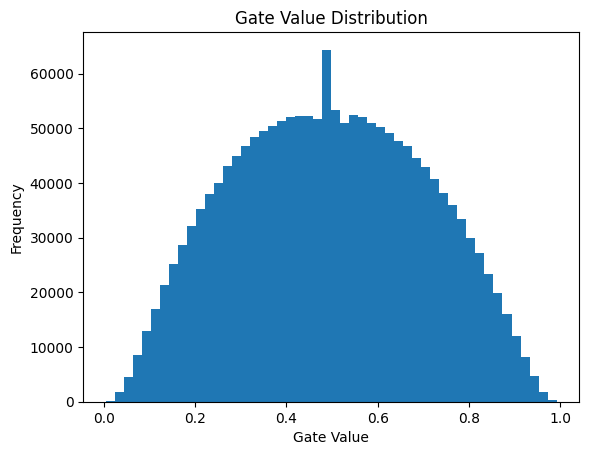

In [72]:
best_model = models[1]

gates = []

for module in best_model.modules():
    if isinstance(module, PrunableLinear):
        g = torch.sigmoid(module.gate_scores).detach().cpu().numpy().flatten()
        gates.extend(g)

plt.hist(gates, bins=50)
plt.title("Gate Value Distribution")
plt.xlabel("Gate Value")
plt.ylabel("Frequency")
plt.show()